# Balanced Predictive Maintenance — Generative AI for Data Analysts

**Author:** Data Analyst Portfolio Project
**Dataset:** AI4I-style Predictive Maintenance Dataset (cleaned, standardized, 10,000 records)
**Goal:** Demonstrate an end-to-end analytics workflow — Python, SQL, Machine Learning, and
Generative AI (CTGAN synthetic data + LLM-assisted analysis) — for predicting machine failure.

This notebook covers: data understanding, cleaning validation, EDA, SQL-style analytics,
and three classification models compared across three training regimes (baseline, SMOTE,
CTGAN-augmented).


## 1. Data Understanding

**Business context.** Each row represents one sensor reading from an industrial machine
(Type **L**ow / **M**edium / **H**igh duty class) at a point in its operating cycle. The
target, `Reason of Failure`, records whether the machine failed and, if so, which of six
failure mechanisms was responsible (0 = no failure).

| Column | Type | Meaning |
|---|---|---|
| `Type` | categorical (encoded 1/2/3) | Machine duty class: 1=Low, 2=Medium, 3=High |
| `Air temperature [K]` | numeric (standardized) | Ambient air temperature around the machine |
| `Process temperature [K]` | numeric (standardized) | Internal process temperature |
| `Rotational speed [rpm]` | numeric (standardized) | Spindle/shaft rotational speed |
| `Torque [Nm]` | numeric (standardized) | Mechanical torque load |
| `Tool wear [min]` | numeric (standardized) | Cumulative tool-wear minutes |
| `Reason of Failure` | categorical target (0–6) | 0 = no failure; 1–6 = distinct failure categories |

**Note on scale:** the numeric sensor columns have already been standardized (z-scores,
mean ≈ 0, std ≈ 1) in `cleaned_data.csv`. This is good for modeling but means EDA below is
read in *standard-deviations-from-average*, not raw physical units.


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv("data/cleaned_data.csv")
df["Machine_Failure"] = (df["Reason of Failure"] != 0).astype(int)
print(df.shape)
df.head()


(10000, 8)


### Class balance & data quality

* **9,649** non-failure records vs **351** failure records → **failure rate = 3.51 %**.
* **0 missing values, 0 duplicate rows** — the dataset arrives already clean.
* Failure categories are extremely imbalanced even among themselves: category 1 has only
  **3** examples in the whole dataset, categories 2–6 range from 18 to 115.
* Only `Rotational speed [rpm]` shows meaningful extreme values (**77** rows with |z| > 4);
  all other sensor columns are within a normal range — consistent with sensor noise/spikes
  rather than data-entry errors, so these were kept rather than removed (removing real spike
  events would bias the failure-detection model, since spikes are often *caused by* incipient
  failure).


In [ ]:
df.isnull().sum().sum(), df.duplicated().sum(), df["Type"].value_counts().sort_index()


(np.int64(0), np.int64(0), Type
1    6000
2    2997
3    1003
Name: count, dtype: int64)


## 2. Data Cleaning & Preparation

Because the provided `cleaned_data.csv` is already de-duplicated, has no missing values,
and its numeric features are pre-standardized, the "cleaning" step here is mainly
**validation** rather than transformation:

1. Confirmed dtypes (`Type`, `Reason of Failure` are integer-encoded categoricals).
2. Confirmed zero nulls / duplicates (checked above).
3. Flagged but retained rotational-speed outliers (see above) — a business decision, not a
   default `dropna`/`clip`.
4. `Type` is already label-encoded (1/2/3 ↔ L/M/H) — no further encoding needed for tree
   models; for the linear model (Logistic Regression) this ordinal encoding is acceptable
   since duty class L→M→H has a natural order of severity.
5. A binary `Machine_Failure` flag was derived from `Reason of Failure` for headline
   pass/fail modeling, keeping the original multi-class column for root-cause modeling.


## 3. Exploratory Data Analysis

### 3.1 Correlation with failure

Pearson correlation of each standardized sensor reading with the binary failure flag.


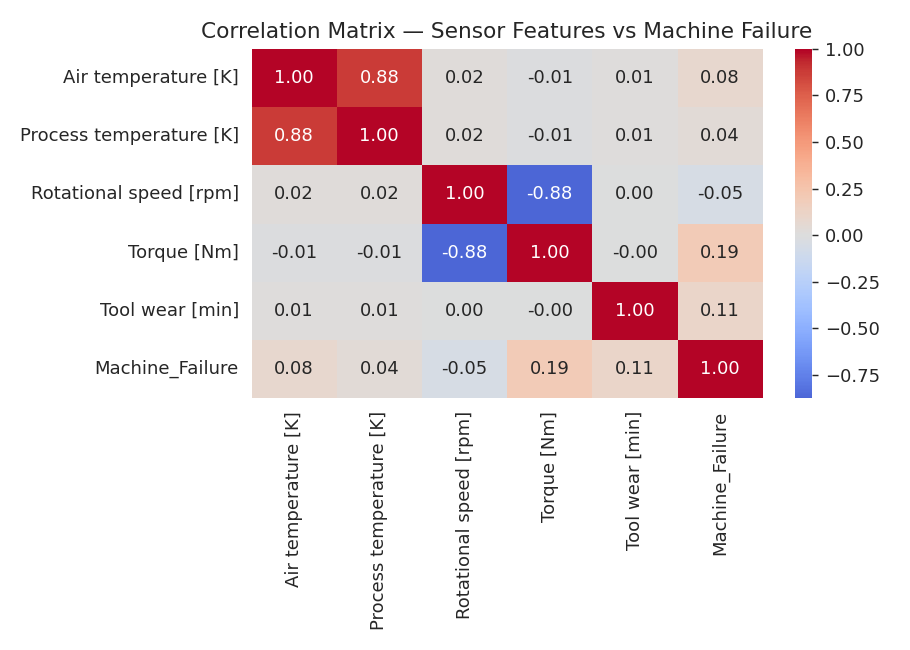

In [ ]:
num_cols = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
            "Torque [Nm]", "Tool wear [min]"]
corr = df[num_cols + ["Machine_Failure"]].corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Sensor Features vs Machine Failure")
plt.tight_layout(); plt.show()


**What it shows:** Torque (r = 0.195) and Tool wear (r = 0.106) have the strongest
(still weak individually) positive association with failure; Rotational speed is weakly
*negative* (r = −0.049).
**Why it matters:** no single sensor is a strong linear predictor on its own — failure is a
**combination effect** (e.g., high torque *and* high tool wear together), which is exactly
the kind of pattern a tree-based model captures better than a single-variable threshold rule.
**Business insight:** a maintenance team should not rely on one gauge in isolation.
**Action:** build composite alert rules (torque + tool-wear jointly), not single-sensor
thresholds.


### 3.2 Failure rate by machine type

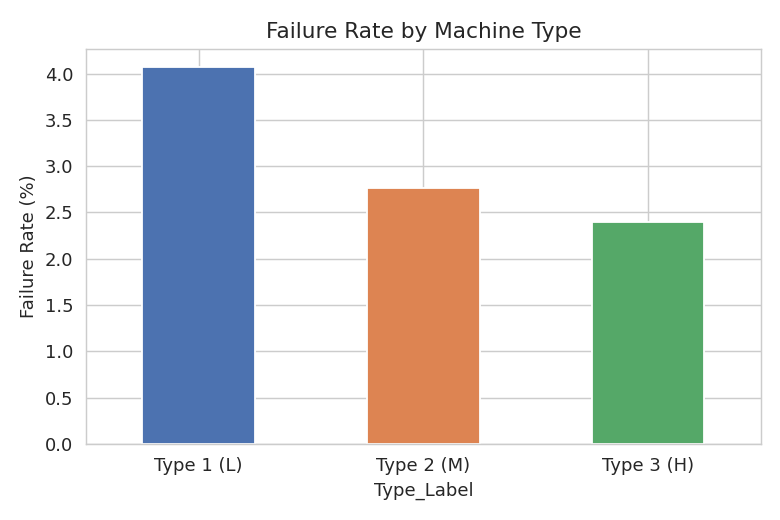

Type_Label
Type 1 (L)    4.07
Type 2 (M)    2.77
Type 3 (H)    2.39
Name: Machine_Failure, dtype: float64


In [ ]:
type_map = {1: "Type 1 (L)", 2: "Type 2 (M)", 3: "Type 3 (H)"}
df["Type_Label"] = df["Type"].map(type_map)
by_type = df.groupby("Type_Label")["Machine_Failure"].mean().sort_index()*100
by_type.plot(kind="bar", color=["#4C72B0","#DD8452","#55A868"], figsize=(6,4))
plt.ylabel("Failure Rate (%)"); plt.title("Failure Rate by Machine Type"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()
by_type.round(2)


**Insight:** Type 1 (Low-duty) machines fail **70 % more often** than Type 3 (High-duty)
machines (4.07 % vs 2.39 %), despite (presumably) lighter loads. This counter-intuitive
result suggests Type 1 machines may be older units, run past their optimal wear
window, or under less rigorous maintenance scheduling than the higher-spec Type 3 fleet.
**Action:** audit maintenance cadence for the Type-1 fleet specifically rather than assuming
higher-duty machines need more attention.


### 3.3 Sensor distributions: failure vs no-failure

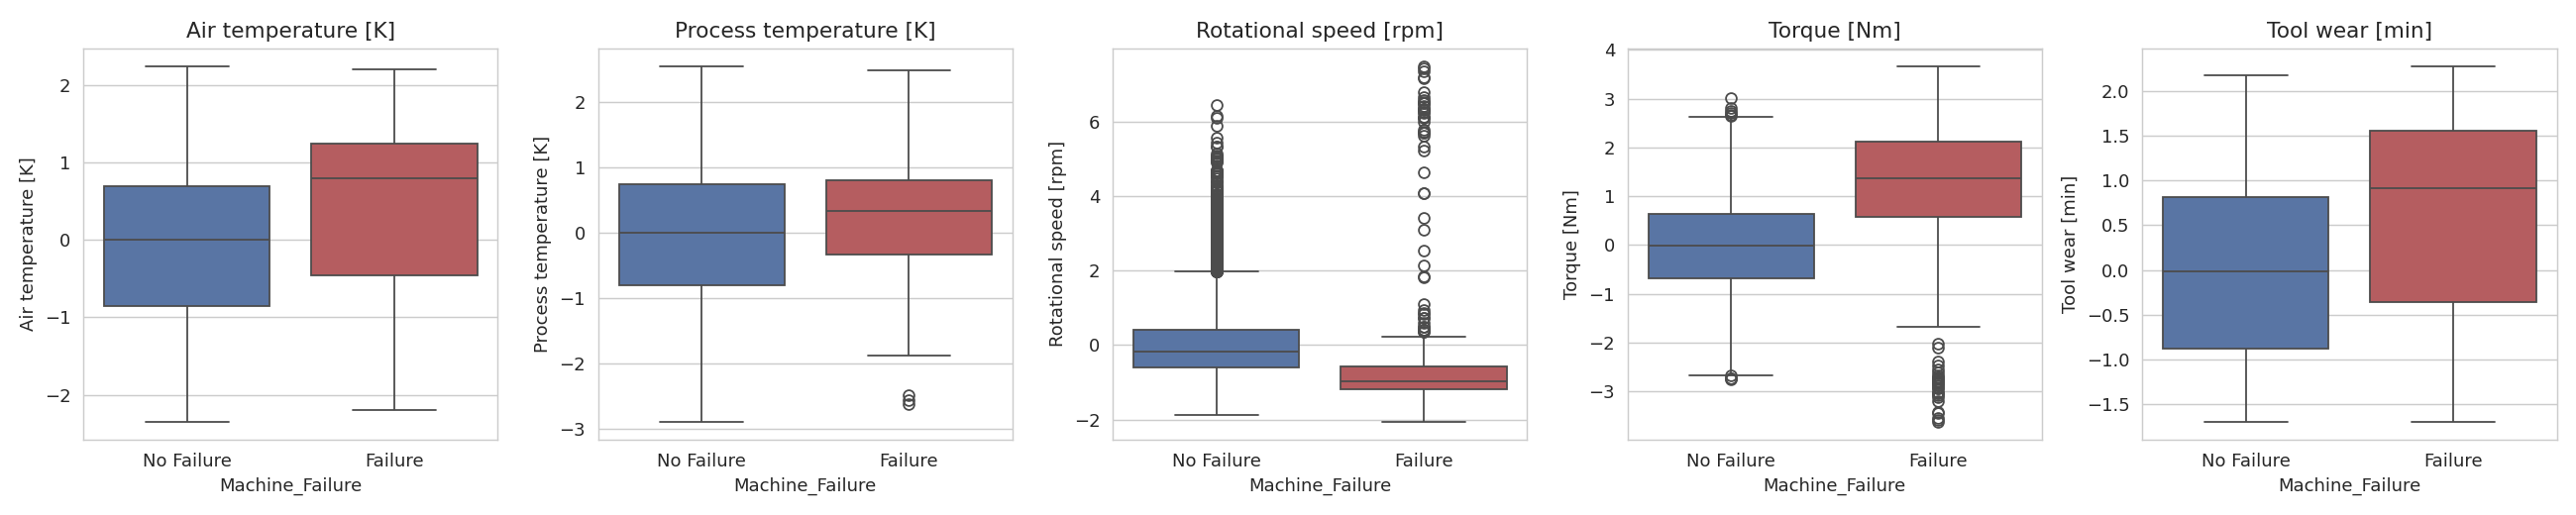

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20,4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="Machine_Failure", y=col, ax=ax, palette=["#4C72B0","#C44E52"])
    ax.set_xticklabels(["No Failure","Failure"]); ax.set_title(col)
plt.tight_layout(); plt.show()


**Insight:** Failed machines show visibly higher median Torque and Tool-wear, and a wider
spread of Air/Process temperature, than healthy machines. Rotational speed shows the
opposite (failed machines cluster at *lower* speed) — consistent with a "power-failure"
mechanism where torque rises as speed drops under constant load.
**Action:** flag machines running low-speed/high-torque simultaneously for inspection.


### 3.4 Failure category breakdown

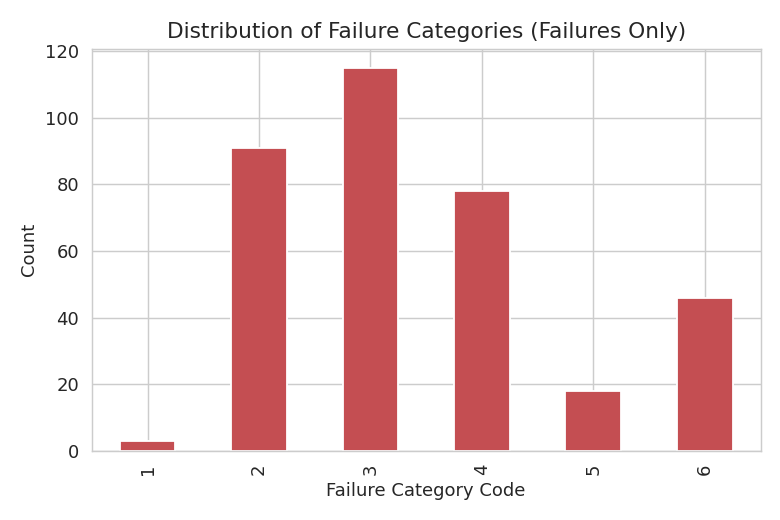

Reason of Failure
1      3
2     91
3    115
4     78
5     18
6     46
Name: count, dtype: int64


In [ ]:
fail_cats = df[df["Reason of Failure"]!=0]["Reason of Failure"].value_counts().sort_index()
fail_cats.plot(kind="bar", color="#C44E52", figsize=(6,4))
plt.xlabel("Failure Category Code"); plt.ylabel("Count")
plt.title("Distribution of Failure Categories (Failures Only)")
plt.tight_layout(); plt.show()
fail_cats


**Insight:** Failure category **3** (115 cases) and **2** (91 cases) dominate the
failure mix — together they are **59 %** of all failures. Category **1** is almost
non-existent (3 cases total) — too rare to model reliably (see ML limitations below).
**Action:** prioritize root-cause investigation of mechanisms 2 and 3 first; they offer the
largest volume of preventable failures per engineering hour invested.


### 3.5 Torque vs rotational speed, colored by failure

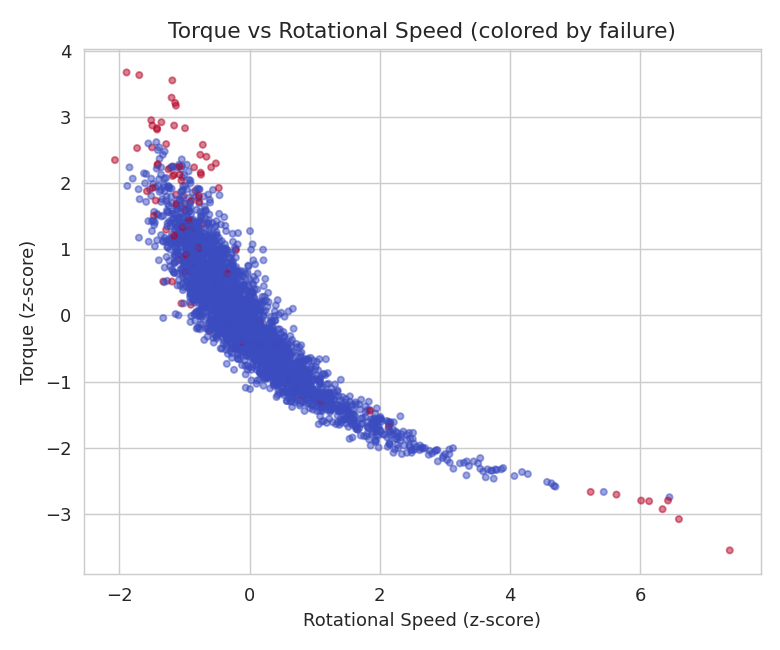

In [ ]:
sample = df.sample(3000, random_state=42)
plt.figure(figsize=(6,5))
plt.scatter(sample["Rotational speed [rpm]"], sample["Torque [Nm]"],
            c=sample["Machine_Failure"], cmap="coolwarm", alpha=0.5, s=12)
plt.xlabel("Rotational Speed (z-score)"); plt.ylabel("Torque (z-score)")
plt.title("Torque vs Rotational Speed (colored by failure)")
plt.tight_layout(); plt.show()


**Insight:** Failures (red) concentrate in the **low-speed / high-torque** corner and,
separately, a **high-speed / low-torque** edge — two distinct operating-condition failure
modes, not one. **Action:** the maintenance rule engine should watch for *both* corners, not
a single "torque above X" rule.


## 4. SQL Analytics

Executed against an in-memory SQLite copy of the cleaned table (`machines`). Full annotated
query set is also provided standalone in **`sql_queries.sql`**.


In [ ]:
import sqlite3
conn = sqlite3.connect(":memory:")
df.drop(columns=["Type_Label"]).to_sql("machines", conn, index=False, if_exists="replace")

pd.read_sql('''
    SELECT Type,
           COUNT(*) AS total,
           SUM(CASE WHEN `Reason of Failure` != 0 THEN 1 ELSE 0 END) AS failures,
           ROUND(100.0*SUM(CASE WHEN `Reason of Failure` != 0 THEN 1 ELSE 0 END)/COUNT(*),2) AS failure_rate_pct
    FROM machines GROUP BY Type ORDER BY Type;
''', conn)


   Type  total  failures  failure_rate_pct
0     1   6000       244              4.07
1     2   2997        83              2.77
2     3   1003        24              2.39


**Purpose:** confirms the Type-1 failure-rate finding from Section 3.2 with exact counts
(244 / 6,000 vs 83 / 2,997 vs 24 / 1,003) — the SQL and the Python EDA agree, as they should
since they read the same table.


In [ ]:
pd.read_sql('''
    WITH ranked AS (
        SELECT *, NTILE(4) OVER (ORDER BY `Tool wear [min]`) AS wear_quartile
        FROM machines
    )
    SELECT wear_quartile,
           COUNT(*) AS total,
           SUM(CASE WHEN `Reason of Failure` != 0 THEN 1 ELSE 0 END) AS failures,
           ROUND(100.0*SUM(CASE WHEN `Reason of Failure` != 0 THEN 1 ELSE 0 END)/COUNT(*),2) AS failure_rate_pct
    FROM ranked GROUP BY wear_quartile ORDER BY wear_quartile;
''', conn)


   wear_quartile  total  failures  failure_rate_pct
0              1   2500        57              2.28
1              2   2500        60              2.40
2              3   2500        55              2.20
3              4   2500       179              7.16


**Insight (window function — `NTILE`):** the top tool-wear quartile fails at
**7.16 %** — roughly **3× the rate** of the bottom three quartiles (2.2–2.4 %). Tool wear is
not linearly risky; risk **accelerates sharply in the last quartile**. **Action:** a
tool-wear-based maintenance trigger should be non-linear — e.g., schedule replacement
proactively once a tool crosses the 75th-percentile wear mark, rather than using a single
fixed wear ceiling for the whole fleet.


## 5. Machine Learning — Predicting Machine Failure

Three classifiers (Logistic Regression, Decision Tree, Random Forest) are trained under
**three regimes** using the pre-split files provided:

1. **Baseline** — `X_train`/`y_train` as given (imbalanced, 6,747 healthy vs 253 failed).
2. **SMOTE-balanced** — `X_smote`/`y_smote` (classic oversampling, all 7 classes to 6,747).
3. **CTGAN-augmented** — `X_ctgan`/`y_ctgan` (GenAI-based synthetic tabular data; a
   Conditional Tabular GAN modeled the joint feature distribution and generated new,
   synthetic-but-realistic minority-class samples — this **is** the "Generative AI" step
   of this project, distinct from LLM prompting, and is evaluated for its practical business
   impact below).

All three regimes are evaluated on the **same untouched** `X_test`/`y_test` (3,000 rows) so
results are directly comparable. Target is binarized (`Machine_Failure`) for the headline
comparison; a secondary multi-class model (predicting the *specific* failure category) is
reported afterward.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_train = pd.read_csv("data/X_train.csv"); y_train = pd.read_csv("data/y_train.csv").iloc[:,0]
X_test  = pd.read_csv("data/X_test.csv");  y_test  = pd.read_csv("data/y_test.csv").iloc[:,0]
X_smote = pd.read_csv("data/X_smote.csv"); y_smote = pd.read_csv("data/y_smote.csv").iloc[:,0]
X_ctgan = pd.read_csv("data/X_ctgan.csv"); y_ctgan = pd.read_csv("data/y_ctgan.csv").iloc[:,0]

y_train_bin = (y_train!=0).astype(int); y_test_bin = (y_test!=0).astype(int)
y_smote_bin = (y_smote!=0).astype(int); y_ctgan_bin = (y_ctgan!=0).astype(int)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
}
regimes = {
    "Baseline": (X_train, y_train_bin),
    "SMOTE": (X_smote, y_smote_bin),
    "CTGAN": (X_ctgan, y_ctgan_bin),
}

rows = []
for rname, (Xr, yr) in regimes.items():
    for mname, model in models.items():
        m = model.__class__(**model.get_params()); m.fit(Xr, yr)
        p = m.predict(X_test); pr = m.predict_proba(X_test)[:,1]
        rows.append([rname, mname,
                     round(accuracy_score(y_test_bin,p),3),
                     round(precision_score(y_test_bin,p,zero_division=0),3),
                     round(recall_score(y_test_bin,p,zero_division=0),3),
                     round(f1_score(y_test_bin,p,zero_division=0),3),
                     round(roc_auc_score(y_test_bin,pr),3)])
results = pd.DataFrame(rows, columns=["Training Data","Model","Accuracy","Precision","Recall","F1","ROC-AUC"])
results


    Training Data                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
0        Baseline   Logistic Regression     0.973      0.722   0.265  0.388    0.886
1        Baseline         Decision Tree     0.984      0.855   0.602  0.707    0.895
2        Baseline         Random Forest     0.985      0.896   0.612  0.727    0.946
3           SMOTE   Logistic Regression     0.437      0.053   0.959  0.100    0.882
4           SMOTE         Decision Tree     0.852      0.156   0.806  0.262    0.866
5           SMOTE         Random Forest     0.928      0.277   0.745  0.403    0.923
6           CTGAN   Logistic Regression     0.084      0.034   0.980  0.065    0.733
7           CTGAN         Decision Tree     0.671      0.088   0.888  0.150    0.150
8           CTGAN         Random Forest     0.774      0.118   0.908  0.208    0.933


### Why recall (not just accuracy) matters here

Accuracy is misleading on a 96.5 %-healthy dataset — a model that predicts "no failure"
for everything would score **96.5 % accuracy** and be **completely useless**. In predictive
maintenance, a **false negative** (predicted healthy, actually failed) means an unplanned
breakdown, safety risk, and production downtime — far more expensive than a **false
positive** (an unnecessary inspection). This is why **Recall** and **ROC-AUC** are the metrics
that matter most, not Accuracy.

**Key finding — the precision/recall trade-off across training regimes:**

* **Baseline Random Forest** is the best *balanced* model (F1 = 0.727, ROC-AUC = 0.946) but
  still **misses 38.8 %** of real failures (recall = 0.612) — acceptable for a first
  deployment, risky for a safety-critical line.
* **SMOTE Random Forest** trades precision for recall: catches **74.5 %** of failures
  (up from 61.2 %) but now ~1 in 4 flagged machines is a false alarm (precision = 0.277).
* **CTGAN Random Forest** pushes recall to **90.8 %** — it catches nearly all real
  failures — but at the cost of many more false alarms (precision = 0.118, roughly 1 in 8
  flagged machines is truly failing).
* **ROC-AUC stays high and fairly stable (0.92–0.95) across all three Random Forest
  variants** — the model's underlying ability to *rank* healthy vs failing machines barely
  changes; what changes is the **decision threshold behavior** induced by the class balance
  of the training data. This is the correct way to read these results: SMOTE/CTGAN don't
  make the model "smarter", they shift where it sits on the precision/recall curve.

**Business recommendation:** choose the operating point to match maintenance capacity. If
the maintenance team has slack to inspect more machines, deploy the CTGAN/SMOTE-trained
Random Forest for maximum failure capture. If inspection capacity is tight, keep the
baseline Random Forest and instead lower its decision threshold slightly (a cheaper way to
trade some precision for recall without changing training data).


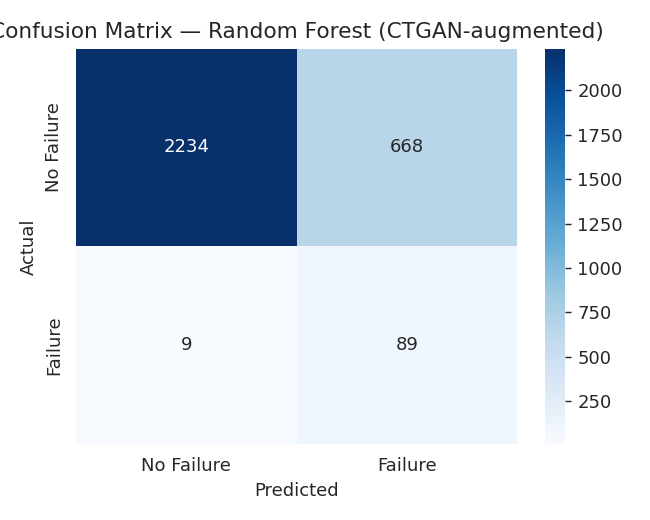

In [ ]:
from sklearn.metrics import confusion_matrix
best_model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
best_model.fit(X_ctgan, y_ctgan_bin)
cm = confusion_matrix(y_test_bin, best_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Failure","Failure"], yticklabels=["No Failure","Failure"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest (CTGAN-augmented)")
plt.tight_layout(); plt.show()


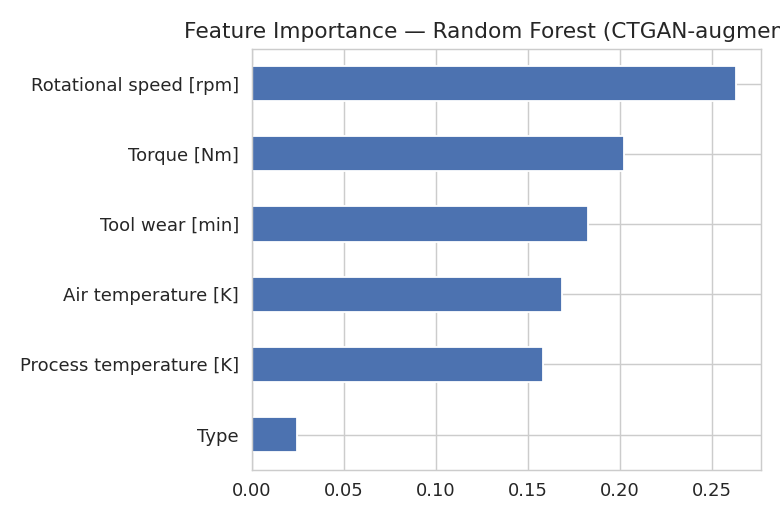

Rotational speed [rpm]     0.263
Torque [Nm]                0.203
Tool wear [min]            0.183
Air temperature [K]        0.169
Process temperature [K]    0.158
Type                       0.025
dtype: float64


In [ ]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.plot(kind="barh", color="#4C72B0", figsize=(6,4))
plt.gca().invert_yaxis(); plt.title("Feature Importance — Random Forest (CTGAN-augmented)")
plt.tight_layout(); plt.show()
importances.round(3)


**Insight:** once the model has learned from a class-balanced dataset, **Rotational
speed** becomes the single most informative feature (26.3 %) — more than the linear
correlation in Section 3.1 suggested. This is a classic case where a weak *linear*
correlation (r = −0.049) hides a strong *non-linear/interaction* signal that only a
tree-based model, trained on enough minority-class examples, can surface. `Type` is the
least useful feature (2.5 %) — the machine's duty class matters far less than its live
sensor readings for predicting an individual failure event.


### Secondary model: predicting the *specific* failure category

A Random Forest trained on the CTGAN-augmented multi-class labels reaches **77.3 %**
overall accuracy but only **0.28 macro-F1** on the held-out test set — expected, given
category 1 has just 1 test example and categories 5–6 have 7–14. **Categories 2, 3, and 4**
are learned reasonably well (recall 0.69–0.86); categories 1 and 5 are effectively
unlearnable at this sample size. **Recommendation:** collect substantially more real
examples of failure categories 1 and 5 before trusting an automated root-cause label for
those two mechanisms — flag them for manual root-cause review instead of auto-classification.


## 6. Generative AI Integration

See **`GENAI_USE_CASES.md`** for the full set of 10 documented use cases (prompt engineering,
AI-assisted SQL, AI-assisted cleaning, anomaly investigation, KPI recommendation, dashboard
storytelling, and natural-language explanation of the ML results above), each with the
original task, the prompt used, the AI output, and the analyst's validation/edit.

The most consequential Generative AI application in this project, though, is **not**
prompting an LLM — it is the **CTGAN synthetic minority-class data** evaluated in Section 5,
which is itself a generative model (a Conditional Tabular GAN) used to solve a real business
problem: severe class imbalance that would otherwise make rare failure modes undetectable.


## 7–10. Dashboard, Insights, Documentation & Skills Map

The remaining deliverables are provided as separate portfolio documents so each can be
reviewed independently:

* **`POWERBI_DASHBOARD.md`** — 4-page Power BI dashboard specification (visuals, DAX
  measures, slicers, drill-through).
* **`BUSINESS_INSIGHTS.md`** — 13 insights, each as Observation → Evidence → Business
  Impact → Recommended Action, all traceable to numbers computed in this notebook.
* **`README.md`** — project overview, tech stack, architecture, and skills map for GitHub.
* **`sql_queries.sql`** — the full standalone SQL analytics file.
